In [2]:
%pip install torch torchvision opencv-python matplotlib numpy pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


(512, 512, 3)


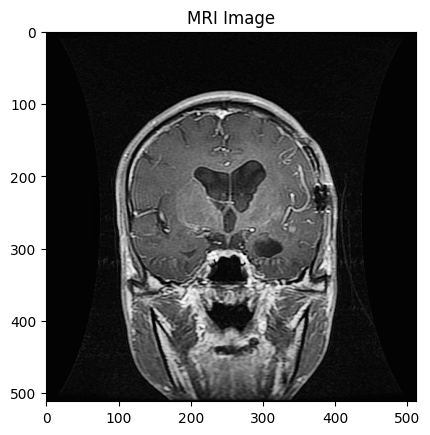

In [43]:
image_path = "../dataset/Segmentation/Glioma/enh_209.png"

image = cv2.imread(image_path)

print(image.shape)

plt.imshow(image)
plt.title("MRI Image")
plt.show()

(512, 512)


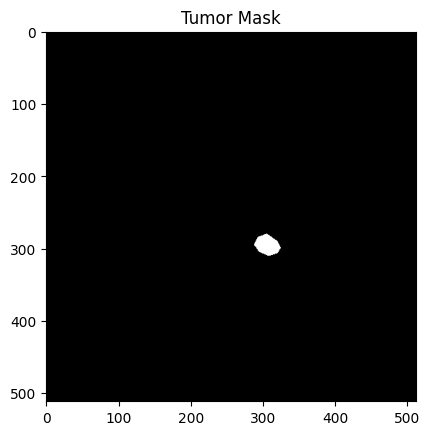

In [5]:
mask_path = "../dataset/Segmentation/Glioma/enh_209_mask.png"

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print(mask.shape)

plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.show()

In [45]:
folder_path = "../dataset/Segmentation/Glioma"

all_files = os.listdir(folder_path)

images = []
masks = []

for file in all_files:

    if "_mask" in file:
        masks.append(file)
    else:
        images.append(file)

print("Total Images:", len(images))
print("Total Masks:", len(masks))

print(images[:5])
print(masks[:5])

Total Images: 554
Total Masks: 554
['enh_1841.png', 'enh_1842.png', 'enh_1843.png', 'enh_1844.png', 'enh_1845.png']
['enh_1841_mask.png', 'enh_1842_mask.png', 'enh_1843_mask.png', 'enh_1844_mask.png', 'enh_1845_mask.png']


In [6]:
class BrainTumorDataset(Dataset):

    def __init__(self, folder_path):

        self.folder_path = folder_path

        self.images = []

        all_files = os.listdir(folder_path)

        for file in all_files:

            if "_mask" not in file:
                self.images.append(file)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        mask_name = image_name.replace(".png", "_mask.png")

        image_path = os.path.join(self.folder_path, image_name)
        mask_path = os.path.join(self.folder_path, mask_name)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256))

        image = image / 255.0
        mask = (mask > 127).astype(np.float32)

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [7]:
dataset = BrainTumorDataset(
    "../dataset/Segmentation/Glioma"
)

print("Total Samples:", len(dataset))

Total Samples: 554


In [8]:
train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("DataLoader Ready")

DataLoader Ready


In [9]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256])


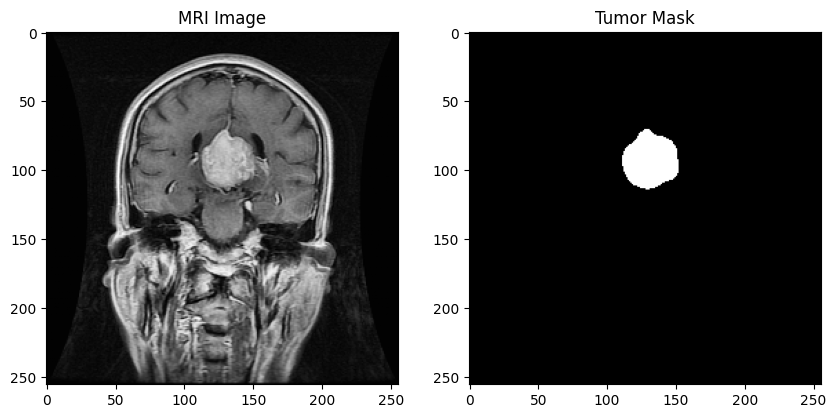

In [50]:
image = images[0].squeeze().numpy()
mask = masks[0].squeeze().numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("MRI Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")

plt.show()

In [10]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [11]:
class UNet(nn.Module):

    def __init__(self):
        super(UNet, self).__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        bn = self.bottleneck(p3)

        up3 = self.up3(bn)
        up3 = torch.cat([up3, d3], dim=1)
        up3 = self.conv3(up3)

        up2 = self.up2(up3)
        up2 = torch.cat([up2, d2], dim=1)
        up2 = self.conv2(up2)

        up1 = self.up1(up2)
        up1 = torch.cat([up1, d1], dim=1)
        up1 = self.conv1(up1)

        return torch.sigmoid(self.final(up1))

In [12]:
model = UNet().to(device)

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (

In [16]:
def dice_loss(pred, target, smooth=1):

    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum()

    return 1 - (
        (2. * intersection + smooth)
        /
        (pred.sum() + target.sum() + smooth)
    )


def combined_loss(pred, target):

    bce = nn.BCELoss()(pred, target)

    dice = dice_loss(pred, target)

    return bce + dice

In [17]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer Ready")

Optimizer Ready


In [ ]:
num_epochs = 8

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss/len(train_loader):.4f}")

Epoch [1/8] Loss: 2.8354
Epoch [2/8] Loss: 2.8789
Epoch [3/8] Loss: 2.8769
Epoch [4/8] Loss: 2.8756
Epoch [5/8] Loss: 2.8831


In [ ]:
torch.save(
    model.state_dict(),
    "../saved_models/unet_model.pth"
)

print("Model Saved Successfully")

Model Saved Successfully
